### Posterior predictive check (prova)

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions


import cmdstanpy
import os
from pathlib import Path

import os, sys
from pathlib import Path
def set_project_root():
        
    # Find and navigate to Progetto_Bayesian_Statistics
    current = Path.cwd()

    # Check if we're already there
    if current.name == 'Progetto_Bayesian_Statistics':
        print(f"Already in project root: {current}")
    else:
        # Search up to parent directories
        for parent in [current] + list(current.parents):
            if parent.name == 'Progetto_Bayesian_Statistics':
                os.chdir(parent)
                print(f"Changed to: {parent}")
                break
        else:
            raise FileNotFoundError("Progetto_Bayesian_Statistics folder not found")

    # Verify
    assert Path('src').exists(), "src/ folder not found"
    print(f"Current directory: {os.getcwd()}")
    print(f"Contents: {os.listdir()}")


    # Create ./stan folder if does not exists
    STAN_PATH = "./src/stan_models/"
    print(cmdstanpy.cmdstan_path())
    return STAN_PATH

STAN_PATH = set_project_root()
print("cwd:", os.getcwd())
print("first sys.path entries:")
for p in sys.path[:5]:
    print("  ", p)

print("project root guess:", Path().resolve())
print("exists ./src ?", (Path().resolve() / "src").exists())

from src.utils.utils import *

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Already in project root: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Current directory: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
Contents: ['materials', '.DS_Store', 'requirements.txt', 'README.md', 'results', '.gitignore', 'requirements.bk.txt', '.git', 'data', 'src']
/Users/sararedaelli/.cmdstan/cmdstan-2.37.0
cwd: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
first sys.path entries:
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload
   
   /Users/sararedaelli/Library/Python/3.13/lib/python/site-packages
project root guess: /Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics
exists ./src ? True


In [2]:
data, data_donors = transform_data()
glm_data, X_D = get_glm_data(data, data_donors)

[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]


/Users/sararedaelli/Desktop/Progetto_Bayesian_Statistics/src/utils/utils.py:70: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Control'] = data['Control'].replace({'Yes': 1, 'No': 0})


In [3]:
model_names = [("ab_baseline_simple_poi.stan", {})]

models = {}
for key in model_names:
    print(f"Compiling model: {key}")
    glm = CmdStanModel(stan_file=f"{STAN_PATH}/{key[0]}")
    for x in X_D:
        models[(key[0], tuple(key[1].items()), x)] = {"model": glm, "X": X_D[x]}
        new_data = glm_data.copy()
        new_data.update({"X": X_D[x], "p": X_D[x].shape[1]})
        new_data.update(key[1])
        models[(key[0], tuple(key[1].items()), x)]["data"] = new_data

Compiling model: ('ab_baseline_simple_poi.stan', {})


In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def sample_model(key, model_config, sample_config):
    glm_fit = model_config["model"].sample(
        data=model_config["data"], 
        **sample_config
    )
    return key, glm_fit


sample_config = {
    "chains": 4,  
    "parallel_chains": 4,
    "iter_warmup": 2000, 
    "iter_sampling": 6000,
    "show_console": True,
    "adapt_delta": 0.99,  # increase from 0.8
    "max_treedepth": 12, 
}


max_workers = 1
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {
        executor.submit(sample_model, k, v, sample_config): k 
        for k, v in models.items()
    }
    for future in as_completed(futures):
        key, fit = future.result()
        models[key]["fit"] = fit
        models[key]["az"] = az.from_cmdstanpy(fit)
        print(f"✓ Completed: {key}")

print("\n✓ All models fitted")

11:23:00 - cmdstanpy - INFO - Chain [1] start processing
11:23:00 - cmdstanpy - INFO - Chain [2] start processing
11:23:00 - cmdstanpy - INFO - Chain [3] start processing
11:23:00 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)Chain [3] method = sample (Default)
Chain [3] sample
Chain [3] num_samples = 6000
Chain [3] num_warmup = 2000
Chain [3] save_warmup = false (Default)
Chain [3] thin = 1 (Default)
Chain [3] adapt
Chain [3] engaged = true (Default)
Chain [3] gamma = 0.05 (Default)
Chain [3] delta = 0.99
Chain [3] kappa = 0.75 (Default)
Chain [3] t0 = 10 (Default)
Chain [3] init_buffer = 75 (Default)
Chain [3] term_buffer = 50 (Default)
Chain [3] window = 25 (Default)
Chain [3] save_metric = false (Default)
Chain [3] algorithm = hmc (Default)
Chain [3] hmc
Chain [3] engine = nuts (Default)
Chain [3] nuts
Chain [3] max_depth = 12
Chain [3] metric = diag_e (Default)
Chain [3] metric_file =  (Default)
Chain [3] stepsize = 1 (Default)
Chain [3] stepsize_jitter = 0 (Default)
Chain [3] num_chains = 1 (Default)
Chain [3] id = 3
Chain [3] data
Chain [3] file = /var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/tmpz8_eulxb/ycfdtitk.json
Chain [3] init = 2 (Default)
Chain [3] random

11:28:41 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 121.641 seconds (Warm-up)
Chain [1] 218.375 seconds (Sampling)
Chain [1] 340.016 seconds (Total)
Chain [1] 
Chain [1] 
Chain [4] Iteration: 5500 / 8000 [ 68%]  (Sampling)
Chain [2] Iteration: 5500 / 8000 [ 68%]  (Sampling)
Chain [3] Iteration: 5400 / 8000 [ 67%]  (Sampling)
Chain [2] Iteration: 5600 / 8000 [ 70%]  (Sampling)
Chain [4] Iteration: 5600 / 8000 [ 70%]  (Sampling)
Chain [3] Iteration: 5500 / 8000 [ 68%]  (Sampling)
Chain [4] Iteration: 5700 / 8000 [ 71%]  (Sampling)
Chain [2] Iteration: 5700 / 8000 [ 71%]  (Sampling)
Chain [3] Iteration: 5600 / 8000 [ 70%]  (Sampling)
Chain [4] Iteration: 5800 / 8000 [ 72%]  (Sampling)
Chain [2] Iteration: 5800 / 8000 [ 72%]  (Sampling)
Chain [3] Iteration: 5700 / 8000 [ 71%]  (Sampling)
Chain [4] Iteration: 5900 / 8000 [ 73%]  (Sampling)
Chain [2] Iteration: 5900 / 8000 [ 73%]  (Sampling)
Chain [3] Iteration: 5800 / 8000 [ 72%]  (Sampling)
Chain [4] Iter

11:30:25 - cmdstanpy - INFO - Chain [4] done processing


...

Chain [2] 
Chain [2] Elapsed Time: 1090.79 seconds (Warm-up)
Chain [2] 2786.12 seconds (Sampling)
Chain [2] 3876.91 seconds (Total)
Chain [2] 
Chain [2] 
Chain [1] Iteration: 6000 / 8000 [ 75%]  (Sampling)
Chain [1] Iteration: 6100 / 8000 [ 76%]  (Sampling)
Chain [1] Iteration: 6200 / 8000 [ 77%]  (Sampling)
Chain [1] Iteration: 6300 / 8000 [ 78%]  (Sampling)
Chain [1] Iteration: 6400 / 8000 [ 80%]  (Sampling)
Chain [1] Iteration: 6500 / 8000 [ 81%]  (Sampling)
Chain [1] Iteration: 6600 / 8000 [ 82%]  (Sampling)
Chain [1] Iteration: 6700 / 8000 [ 83%]  (Sampling)
Chain [1] Iteration: 6800 / 8000 [ 85%]  (Sampling)
Chain [1] Iteration: 6900 / 8000 [ 86%]  (Sampling)
Chain [1] Iteration: 7000 / 8000 [ 87%]  (Sampling)
Chain [1] Iteration: 7100 / 8000 [ 88%]  (Sampling)
Chain [1] Iteration: 7200 / 8000 [ 90%]  (Sampling)
Chain [1] Iteration: 7300 / 8000 [ 91%]  (Sampling)
Chain [1] Iteration: 7400 / 8000 [ 92%]  (Sampling)
Chain [1] Iteration: 7500 / 8000 [ 93%]  (Sampling)
Chain [1] Iter

13:12:09 - cmdstanpy - INFO - Chain [1] done processing
13:12:09 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: poisson_lpmf: Rate parameter is nan, but must be nonnegative! (in 'ab_baseline_simple_poi.stan', line 40, column 8 to column 45)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ab_baseline_simple_poi.stan', line 48, column 8 to column 48)


Chain [1] 
Chain [1] Elapsed Time: 1105.24 seconds (Warm-up)
Chain [1] 4413.61 seconds (Sampling)
Chain [1] 5518.85 seconds (Total)
Chain [1] 
Chain [1] 


13:12:12 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 5844 iterations at max treedepth (97.4%)
	Chain 2 had 757 iterations at max treedepth (12.6%)
	Chain 3 had 8 iterations at max treedepth (0.1%)
	Chain 4 had 25 iterations at max treedepth (0.4%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


✓ Completed: ('ab_baseline_simple_poi.stan', (), 'X2')

✓ All models fitted


In [5]:
#save results
import os

os.makedirs("./results1/", exist_ok=True)

for key in models:
    poi_glm_data = models[key]["az"]
    
    # Print divergences
    print(f"Divergences {key}: {np.sum(poi_glm_data.sample_stats.diverging.values)}")
    
    # Create filename from key tuple
    filename = f"{'_'.join(str(k) for k in key)}.nc"
    az.to_netcdf(poi_glm_data, f"./results1/{filename}")

Divergences ('ab_baseline_simple_poi.stan', (), 'X'): 0
Divergences ('ab_baseline_simple_poi.stan', (), 'X2_I'): 0
Divergences ('ab_baseline_simple_poi.stan', (), 'X2'): 0


In [19]:
# posterior plot (sorted by fitted mean + log scale)
def posterior_predictive_check(yrep, yobs, q_low=0.05, q_high=0.95):

    # compute mean and CI for every observation
    pred_mean = yrep.mean(axis=0)                      # (N,)
    pred_lo   = np.quantile(yrep, q_low,  axis=0)      # (N,)
    pred_hi   = np.quantile(yrep, q_high, axis=0)      # (N,)

    # identify outliers in original scale
    out = (yobs < pred_lo) | (yobs > pred_hi)

    # sort by fitted mean (in original scale)
    order = np.argsort(pred_mean)

    # apply ordering
    yobs_s      = yobs[order]
    pred_mean_s = pred_mean[order]
    pred_lo_s   = pred_lo[order]
    pred_hi_s   = pred_hi[order]
    out_s       = out[order]

    # x-axis is now "rank by fitted mean"
    x = np.arange(len(yobs))

    # log scale for plotting (safe with zeros)
    yobs_l      = np.log1p(yobs_s)
    pred_mean_l = np.log1p(pred_mean_s)
    pred_lo_l   = np.log1p(pred_lo_s)
    pred_hi_l   = np.log1p(pred_hi_s)

    plt.figure(figsize=(12, 5))

    # predictive band (log scale)
    plt.fill_between(
        x, pred_lo_l, pred_hi_l,
        alpha=0.3,
        label=f"{int((q_high-q_low)*100)}% posterior predictive interval (log1p)"
    )

    # predictive mean (log scale)
    plt.scatter(
        x, pred_mean_l,
        linewidth=2,
        label="log(1 + predicted mean)",
        zorder=2
    )

    # observed inliers/outliers (log scale)
    plt.scatter(
        x[~out_s], yobs_l[~out_s],
        s=18,
        label="Observed (inliers)",
        zorder=3
    )
    plt.scatter(
        x[out_s], yobs_l[out_s],
        s=35,
        color="red",
        label="Observed (outliers)",
        zorder=4
    )

    plt.xlabel("Observations (sorted by fitted mean)")
    plt.ylabel("log(1 + y)")
    plt.title(f"PPC (sorted, log-scale) — outliers: {out.sum()} / {len(out)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # return outliers in original order + ordering used (useful to map back)
    return out, order



<Figure size 1000x500 with 0 Axes>

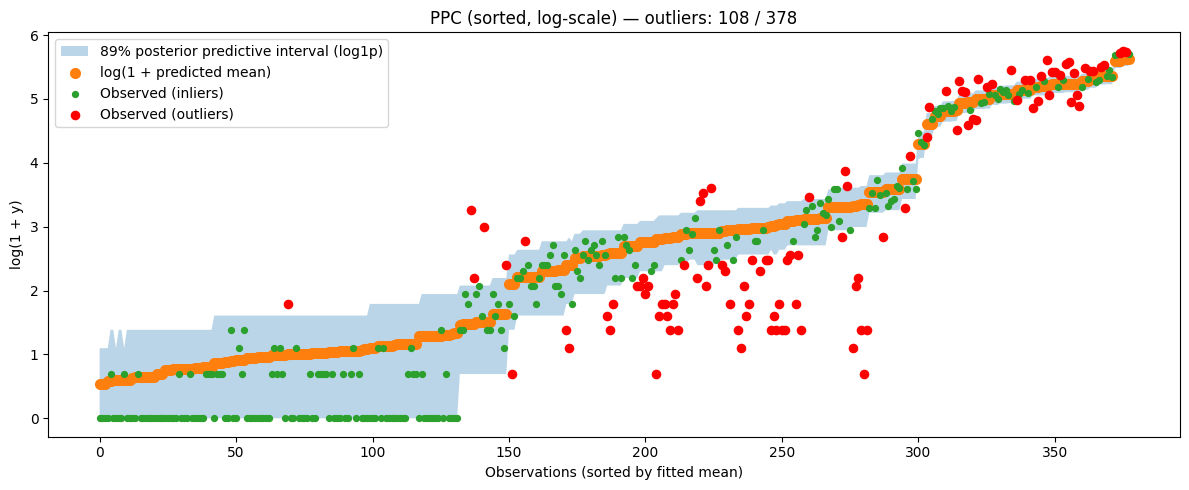

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

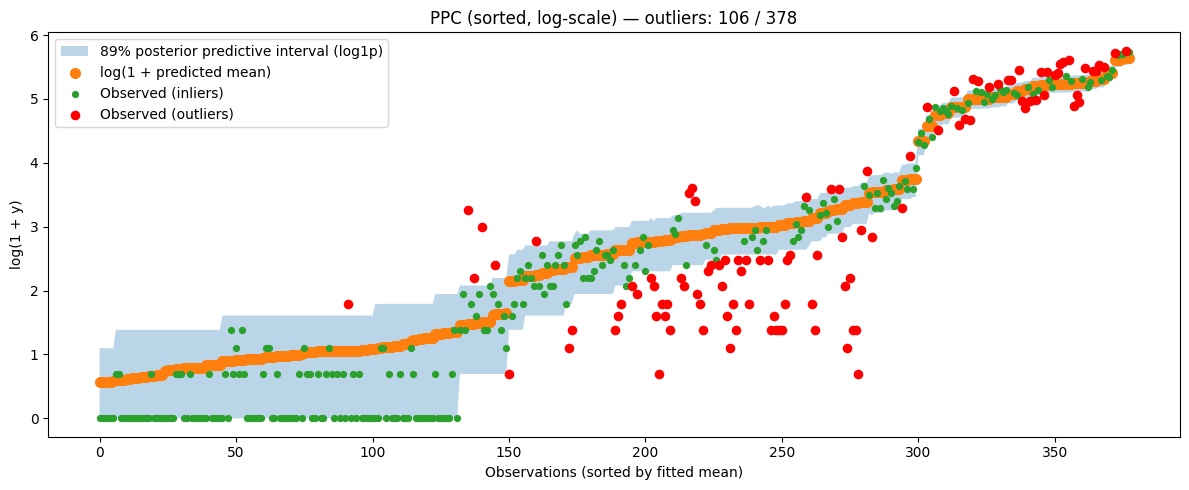

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

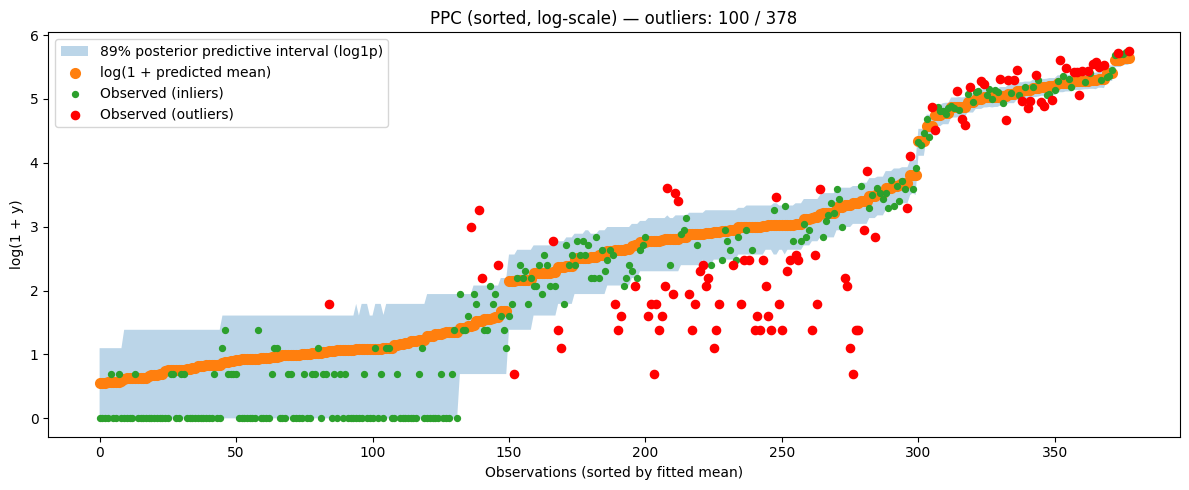

<Figure size 640x480 with 0 Axes>

In [20]:
#posterior predictive check

for key in models:

    idata = models[key]["az"]  

    # Posterior predictive replicates: (chain, draw, N)
    yrep = idata.posterior["Y_rep"].values

    # Observed data 
    yobs = models[key]["data"]["Y"] 
    

    # Flatten chain+draw -> (S, N)
    S = yrep.shape[0] * yrep.shape[1]
    yrep = yrep.reshape(S, yrep.shape[2])

    # Plot
    plt.figure(figsize=(10, 5))
    posterior_predictive_check(yrep, yobs)
    plt.suptitle(f"Posterior Predictive Check: {key}", fontsize=16)
    plt.show()